# OTT Customer Churn Analysis

## Objective
Analyze customer behavior and identify key drivers of churn in a subscription-based OTT platform.

## Workflow
- Data Loading & Cleaning  
- Exploratory Data Analysis (EDA)  
- Feature Engineering  
- Machine Learning (Churn Prediction)  
- Model Evaluation  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")

## Data Loading

In [3]:
df = pd.read_csv('netflix_customer_churn.csv')
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


## Data Overview
Understanding structure, types, and missing values.

In [4]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

## Data Cleaning

In [5]:
df.drop_duplicates(inplace=True)
df['churned'] = df['churned'].astype(int)

## Exploratory Data Analysis (EDA)

### Churn Distribution

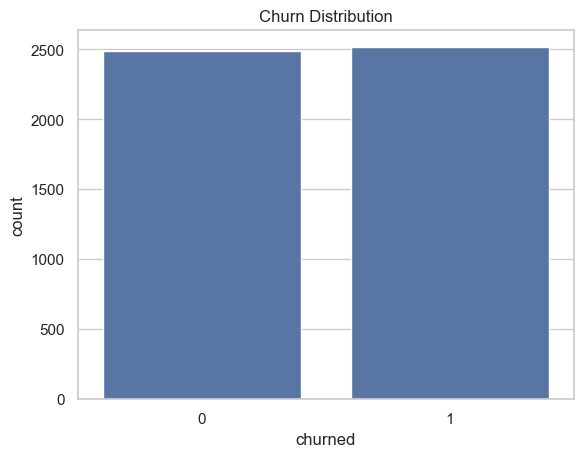

In [6]:
sns.countplot(x='churned', data=df)
plt.title("Churn Distribution")
plt.show()

### Watch Hours vs Churn

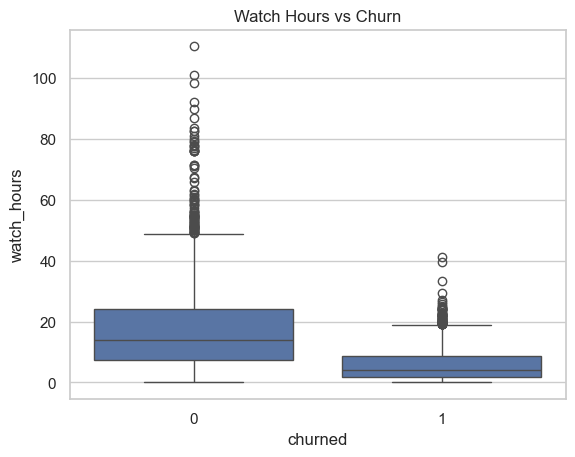

In [7]:
sns.boxplot(x='churned', y='watch_hours', data=df)
plt.title("Watch Hours vs Churn")
plt.show()

### Inactivity vs Churn

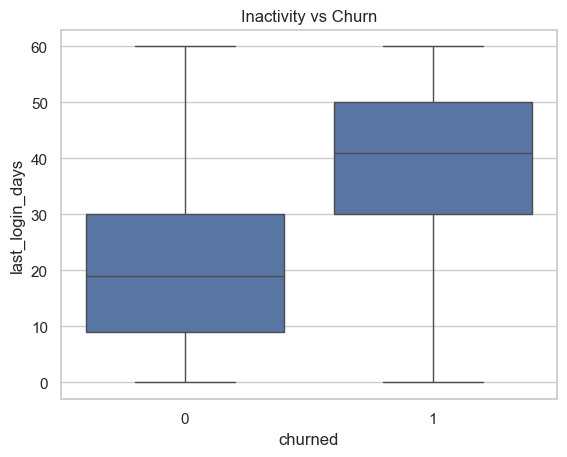

In [8]:
sns.boxplot(x='churned', y='last_login_days', data=df)
plt.title("Inactivity vs Churn")
plt.show()

### Subscription Type vs Churn

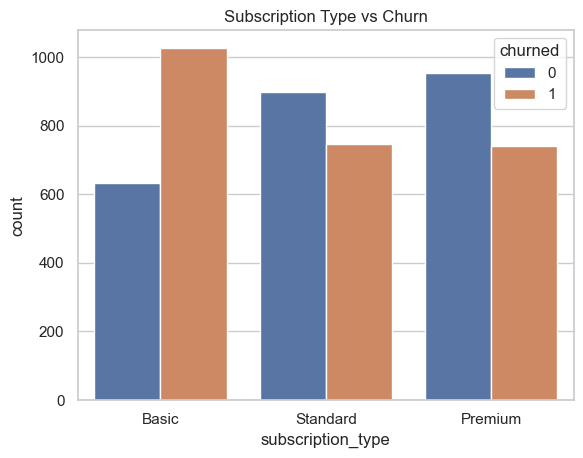

In [9]:
sns.countplot(x='subscription_type', hue='churned', data=df)
plt.title("Subscription Type vs Churn")
plt.show()

### Payment Method vs Churn

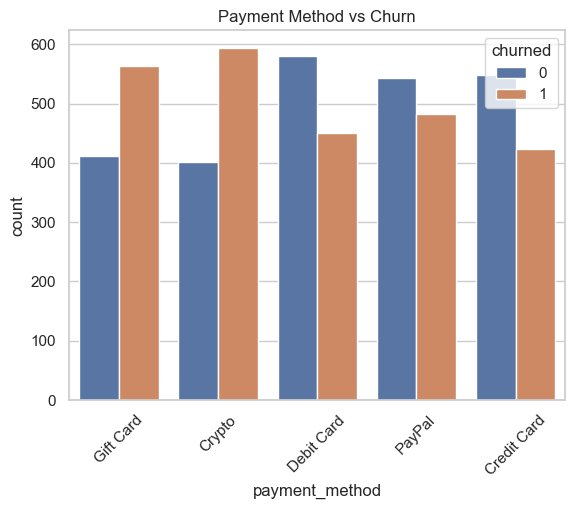

In [10]:
sns.countplot(x='payment_method', hue='churned', data=df)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

### Device vs Churn

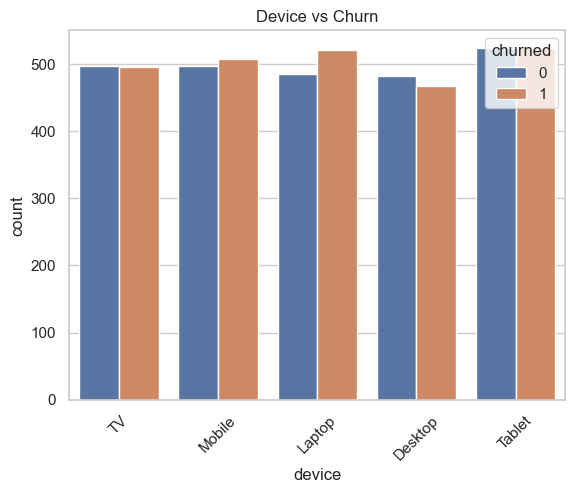

In [11]:
sns.countplot(x='device', hue='churned', data=df)
plt.xticks(rotation=45)
plt.title("Device vs Churn")
plt.show()

### Genre Preference vs Churn

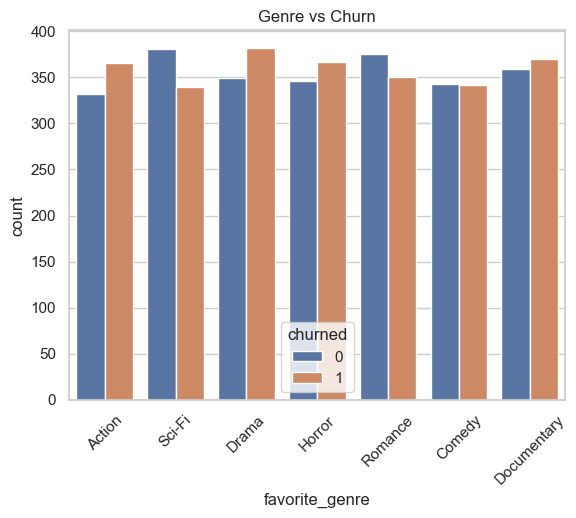

In [12]:
sns.countplot(x='favorite_genre', hue='churned', data=df)
plt.xticks(rotation=45)
plt.title("Genre vs Churn")
plt.show()

### Number of Profiles vs Churn

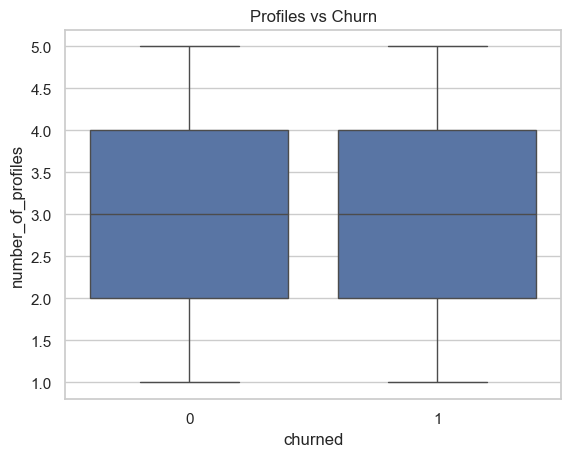

In [13]:
sns.boxplot(x='churned', y='number_of_profiles', data=df)
plt.title("Profiles vs Churn")
plt.show()

## Feature Engineering
Creating meaningful features from raw data.

In [14]:
df['engagement_level'] = pd.cut(df['watch_hours'],
                               bins=[0,5,15,100],
                               labels=['Low','Medium','High'])

df['inactivity_level'] = pd.cut(df['last_login_days'],
                               bins=[0,5,15,100],
                               labels=['Active','At Risk','Inactive'])

## Data Preparation for Machine Learning

In [17]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('churned', axis=1)
y = df_encoded['churned']

## Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Logistic Regression Model

In [19]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.914
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       498
           1       0.90      0.93      0.92       502

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



## Random Forest Model

In [20]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.942


## Feature Importance

In [21]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

avg_watch_time_per_day       0.202385
watch_hours                  0.133286
last_login_days              0.109008
engagement_level_High        0.069984
inactivity_level_Inactive    0.041705
number_of_profiles           0.038444
age                          0.027315
engagement_level_Medium      0.020519
monthly_fee                  0.017288
inactivity_level_At Risk     0.016460
dtype: float64

## Confusion Matrix

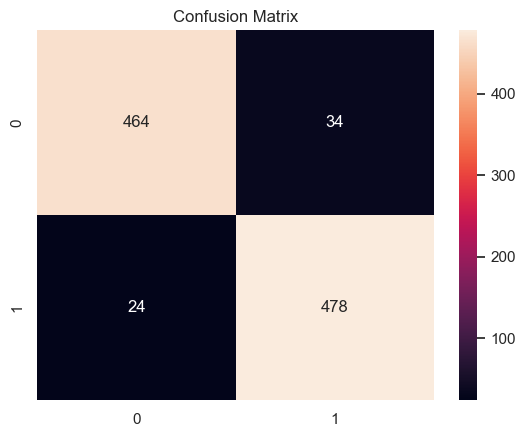

In [22]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## Model Evaluation

- Logistic Regression achieved an accuracy of 91.4% with balanced precision and recall across both classes.
- Random Forest outperformed Logistic Regression with an accuracy of 94.2%, indicating better handling of complex patterns.

### Confusion Matrix Insights
- The model correctly identifies a high proportion of churned customers (high recall for class 1).
- This is important for business use cases where identifying potential churners is critical.

### Feature Importance Insights
- Engagement metrics such as watch hours are among the most important predictors of churn.
- Inactivity (last_login_days) is a strong indicator of customer drop-off.
- Behavioral features contribute more to churn prediction than demographic features.

## Key Insights

- Customers with low watch hours show significantly higher churn, indicating that engagement is a primary driver of retention.
- Users with higher last_login_days (inactive users) are much more likely to churn, highlighting inactivity as a strong churn signal.
- Subscription type impacts retention, with certain plans showing higher churn rates, suggesting pricing or value perception issues.
- Payment method influences churn behavior, which may indicate friction in billing or renewal processes.
- Device usage patterns also affect churn, suggesting differences in user experience across platforms.
- Random Forest model achieved 94.2% accuracy, outperforming Logistic Regression (91.4%), indicating that churn behavior depends on complex, non-linear relationships between features.